In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from geopy.geocoders import Nominatim
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import seaborn as sns

#Phase 1: Trainiing a model to predict order count for a particular region
#Phase 2: Allocating riders using predicted order count AND analytics to optimize travel resources



In [ ]:
df = pd.read_csv('/content/delivery3.csv')
print("Original DataFrame:")

Original DataFrame:


In [ ]:
print(df.head())

   Age  Gender Marital Status Occupation  Monthly Income  \
0   20  Female         Single    Student           50000   
1   24  Female         Single    Student  Below Rs.10000   
2   22    Male         Single    Student  Below Rs.10000   
3   22  Female         Single    Student           50000   
4   22    Male         Single    Student  Below Rs.10000   

  Educational Qualifications  order Count  latitude  longitude  Pin code  \
0              Post Graduate            4   12.9766    77.5993    560001   
1                   Graduate            3   12.9770    77.5773    560009   
2              Post Graduate            3   12.9551    77.6593    560017   
3                   Graduate            6   12.9473    77.5616    560019   
4              Post Graduate            4   12.9850    77.5533    560010   

  Output   Feedback Unnamed: 12  
0    Yes   Positive         Yes  
1    Yes   Positive         Yes  
2    Yes  Negative          Yes  
3    Yes   Positive         Yes  
4    Yes   P

In [ ]:
riders_df=pd.read_csv("/content/Rider2.csv")
riders_df.head()

,Rider ID,Latitude,Longitude,Availability Status
0,RIDER_011,13.0440,77.5599,1
1,RIDER_012,13.0225,77.5452,0
2,RIDER_013,13.0488,77.5334,1
3,RIDER_014,13.0346,77.5367,1
4,RIDER_015,13.0392,77.5628,0


In [ ]:
X =df[['latitude', 'longitude', 'Monthly Income', 'Age', 'Gender', 'Marital Status']]  # Add more relevant features
y =df['order Count']

In [ ]:
df = df[df['order Count'] >= 0]
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,order Count,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,50000,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,50000,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,latitude,longitude,Monthly Income,Age,Gender,Marital Status
0,12.9766,77.5993,50000,20,Female,Single
1,12.9770,77.5773,Below Rs.10000,24,Female,Single
2,12.9551,77.6593,Below Rs.10000,22,Male,Single
3,12.9473,77.5616,50000,22,Female,Single
4,12.9850,77.5533,Below Rs.10000,22,Male,Single


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

print(df.isnull().sum())

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
order Count                   0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 12                   0
dtype: int64


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled)

In [ ]:
X_test_scaled_df.head()


,0,1,2,3,4,5,6,7,8,9
0,0.499085,0.288686,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.428179,0.339781,0.400000,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.479872,0.417883,0.400000,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.499085,0.288686,0.333333,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,0.195334,0.503285,0.733333,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=3, verbose=2, random_state=42)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total t

In [ ]:
print(f"Best parameters: {random_search.best_params_}")

Best parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}


In [ ]:
model = RandomForestRegressor(
    n_estimators=random_search.best_params_['n_estimators'],
    max_depth=random_search.best_params_['max_depth'],
    min_samples_split=random_search.best_params_['min_samples_split'],
    min_samples_leaf=random_search.best_params_['min_samples_leaf'],
    bootstrap=random_search.best_params_['bootstrap'],
    random_state=42
)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                      n_estimators=50, random_state=42)

In [ ]:

y_pred = model.predict(X_test_scaled)

In [ ]:


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 0.8835127048877047
Root Mean Squared Error (RMSE): 1.1917383592592694


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"Mean Cross-Validated MAE: {-scores.mean()}")


Mean Cross-Validated MAE: 0.8760839477726574


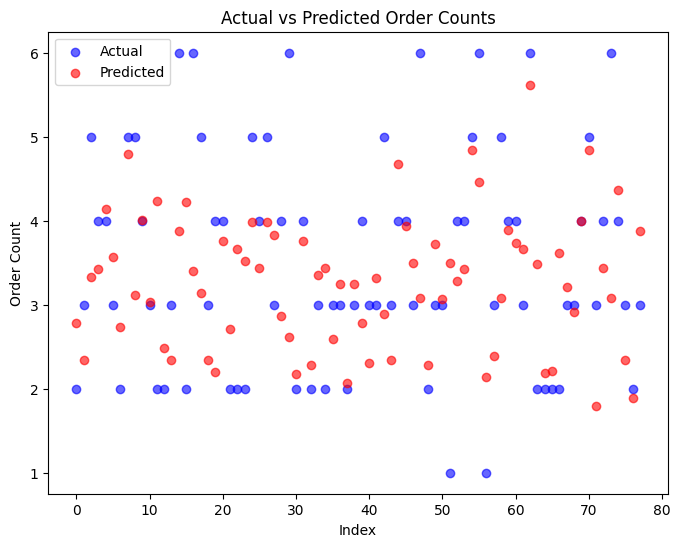

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_test, label="Actual", color='blue', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", color='red', alpha=0.6)
plt.title("Actual vs Predicted Order Counts")
plt.xlabel("Index")
plt.ylabel("Order Count")
plt.legend()
plt.show()


In [ ]:
df['Predicted Order Count'] = model.predict(scaler.transform(X))
df['Predicted Order Count'] = np.maximum(df['Predicted Order Count'], 0)

In [ ]:

df['Predicted Order Count'] = df['Predicted Order Count'].round().astype(int)

(df[['latitude', 'longitude', 'order Count', 'Predicted Order Count']])


,latitude,longitude,order Count,Predicted Order Count
0,12.9766,77.5993,4,2
1,12.9770,77.5773,3,3
2,12.9551,77.6593,3,3
3,12.9473,77.5616,6,3
4,12.9850,77.5533,4,4
...,...,...,...,...
383,12.9766,77.5993,2,2
384,12.9854,77.7081,4,4
385,12.9850,77.5533,5,5
386,12.9770,77.5773,2,2


In [ ]:
num_clusters = 12
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(df[['latitude', 'longitude']])
df['Cluster'] = clusters

cluster_summary = df.groupby('Cluster')['Predicted Order Count'].sum().reset_index()
cluster_summary['Num Riders Needed'] = (cluster_summary['Predicted Order Count'] / 5).apply(np.ceil).astype(int)

geolocator = Nominatim(user_agent="geoapi")
cluster_summary['Cluster Center Address'] = cluster_summary['Cluster'].apply(
    lambda cluster: geolocator.reverse(
        (kmeans.cluster_centers_[cluster][0], kmeans.cluster_centers_[cluster][1]),
        language="en"
    ).address
)
print("Phase 2 - Clustered Areas with Predicted Orders and Riders Assigned:")
(cluster_summary)

Phase 2 - Clustered Areas with Predicted Orders and Riders Assigned:


,Cluster,Predicted Order Count,Num Riders Needed,Cluster Center Address
0,0,95,19,"Gayatri Vihar, Palace Grounds, Bangalore North..."
1,1,120,24,"Inner Ring Road, Amarjyothi Layout, Domlur, Be..."
2,2,74,15,"Giridhama Layout, AGS Layout, Bangalore South,..."
3,3,57,12,"Vivanta by Taj, Whitefield Road, EPIP Zone, Sa..."
4,4,282,57,"D'Lish, Gubbi Thotadappa Road, Railway Colony,..."
5,5,205,41,"New Baiyyappanahalli Extension, Baiyyappanahal..."
6,6,43,9,"Greenwood Regency, Devarabeesanahalli, Doddaka..."
7,7,55,11,"Renaissance Shanks Sunnyside, Kammagondanahall..."
8,8,139,28,National Institute of Mental Health and NeuroS...
9,9,53,11,"Underdoggs, Bellary Road, Byatarayanapura, Sah..."


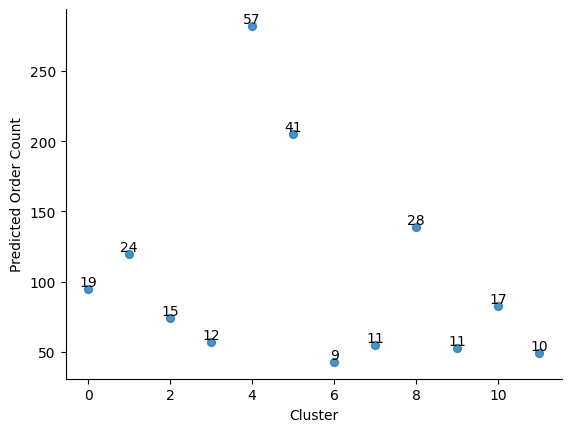

In [ ]:
from matplotlib import pyplot as plt
cluster_summary.plot(kind='scatter', x='Cluster', y='Predicted Order Count', s=32, alpha=.8)
for i, row in cluster_summary.iterrows():
    plt.text(row['Cluster'], row['Predicted Order Count'], row['Num Riders Needed'], ha='center', va='bottom')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [ ]:
from geopy.distance import geodesic
import numpy as np
import pandas as pd

riders_df = riders_df[riders_df['Availability Status'] == '1']

cluster_summary = cluster_summary.rename(columns={'Cluster': 'Assigned Cluster'})

def assign_riders_to_cluster(cluster_centers, cluster_summary, riders_df):
    assignments = []
    for i, center in enumerate(cluster_centers):
        num_needed = cluster_summary.loc[cluster_summary['Assigned Cluster'] == i, 'Num Riders Needed'].values[0]
        riders_df['Distance'] = riders_df.apply(
            lambda rider: geodesic((rider['Latitude'], rider['Longitude']), (center[0], center[1])).km,
            axis=1
        )
        sorted_riders = riders_df.sort_values(by='Distance').head(num_needed)
        assignments.append({
            'Assigned Cluster': i,
            'Cluster Center Address': cluster_summary.loc[cluster_summary['Assigned Cluster'] == i, 'Cluster Center Address'].values[0],
            'Num Riders in Cluster': len(sorted_riders),
            'Rider ID': sorted_riders['Rider ID'].tolist(),
            'Num Riders Needed': num_needed
        })
        riders_df = riders_df[~riders_df['Rider ID'].isin(sorted_riders['Rider ID'])]
    return assignments

assignments = assign_riders_to_cluster(kmeans.cluster_centers_, cluster_summary, riders_df)

rider_assignment = pd.DataFrame(assignments)

print("Phase 3 - Rider Assignment to Areas:")
rider_assignment[['Assigned Cluster', 'Cluster Center Address', 'Num Riders in Cluster', 'Rider ID', 'Num Riders Needed']]


<ipython-input-39-79968547b472>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  riders_df['Distance'] = riders_df.apply(


Phase 3 - Rider Assignment to Areas:


,Assigned Cluster,Cluster Center Address,Num Riders in Cluster,Rider ID,Num Riders Needed
0,0,"Gayatri Vihar, Palace Grounds, Bangalore North...",20,"[RIDER_029, RIDER_118, RIDER_032, RIDER_025, R...",20
1,1,"Inner Ring Road, Amarjyothi Layout, Domlur, Be...",24,"[RIDER_371, RIDER_261, RIDER_084, RIDER_080, R...",24
2,2,"Giridhama Layout, AGS Layout, Bangalore South,...",15,"[RIDER_252, RIDER_056, RIDER_141, RIDER_075, R...",15
3,3,"Vivanta by Taj, Whitefield Road, EPIP Zone, Sa...",12,"[RIDER_067, RIDER_046, RIDER_038, RIDER_099, R...",12
4,4,"D'Lish, Gubbi Thotadappa Road, Railway Colony,...",59,"[RIDER_203, RIDER_267, RIDER_380, RIDER_052, R...",59
5,5,"New Baiyyappanahalli Extension, Baiyyappanahal...",40,"[RIDER_065, RIDER_024, RIDER_189, RIDER_268, R...",40
6,6,"Greenwood Regency, Devarabeesanahalli, Doddaka...",10,"[RIDER_205, RIDER_049, RIDER_158, RIDER_079, R...",10
7,7,"Renaissance Shanks Sunnyside, Kammagondanahall...",11,"[RIDER_026, RIDER_097, RIDER_384, RIDER_051, R...",11
8,8,National Institute of Mental Health and NeuroS...,27,"[RIDER_382, RIDER_270, RIDER_396, RIDER_219, R...",27
9,9,"Underdoggs, Bellary Road, Byatarayanapura, Sah...",11,"[RIDER_146, RIDER_176, RIDER_194, RIDER_282, R...",11
